Netflix is known for its work in data science, AI, and ML, particularly for building strong recommendation models and algorithms that understand customer behavior and patterns. Suppose you are working in a data-driven job role, and you have a dataset of more than 9,000 movies. You need to solve the following questions to help the company make informed business decisions accordingly.

1) What is the most frequent genre of movies released on Netflix?

2) Which has highest votes in vote avg column?

3) What movie got the highest popularity? what's its genre?

4) What movie got the lowest popularity? what's its genre?

5) Which year has the most filmmed movies?


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
MyData = pd.read_csv('mymoviedb.csv',lineterminator='\n')

In [84]:
MyData.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [85]:
MyData.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [86]:
MyData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [87]:
MyData.isnull().sum()

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Vote_Count,0
Vote_Average,0
Original_Language,0
Genre,0
Poster_Url,0


In [88]:
MyData.duplicated().sum()

0

In [89]:
#Bascic statistical property
MyData.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [90]:
#Droping Unnecassary column
MyData['Release_Date'] = pd.to_datetime(MyData['Release_Date'])
print(MyData.dtypes)

Release_Date         datetime64[ns]
Title                        object
Overview                     object
Popularity                  float64
Vote_Count                    int64
Vote_Average                float64
Original_Language            object
Genre                        object
Poster_Url                   object
dtype: object


In [91]:
MyData['Release_Date'] = MyData['Release_Date'].dt.year
MyData.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [92]:
MyData['Release_Date'].dtypes

dtype('int32')

In [94]:
cols = ['Overview','Original_Language','Poster_Url']
MyData.drop(cols,axis=1,inplace= True)

In [95]:
MyData.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [97]:
#Catigorazied column
def Catigorazied_col(MyData,col,labels):
    edges = [MyData[col].describe()['min'],
             MyData[col].describe()['25%'],
             MyData[col].describe()['50%'],
             MyData[col].describe()['75%'],
             MyData[col].describe()['max']
              ]
    MyData[col]= pd.cut(MyData[col],bins=edges,labels=labels,duplicates = 'drop')
    return MyData

In [98]:
labels = ['not_popular','below_avg','average','popular']
Catigorazied_col(MyData,'Vote_Average',labels)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...
9822,1973,Badlands,13.357,896,popular,"Drama, Crime"
9823,2020,Violent Delights,13.356,8,not_popular,Horror
9824,2016,The Offering,13.355,94,not_popular,"Mystery, Thriller, Horror"
9825,2021,The United States vs. Billie Holiday,13.354,152,average,"Music, Drama, History"


In [99]:
MyData['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [100]:
MyData['Vote_Average'].value_counts()

,count
Vote_Average,
not_popular,2467
popular,2450
average,2412
below_avg,2398


In [101]:
#we split the grnres into a list
MyData['Genre'] = MyData['Genre'].str.split(', ')
MyData = MyData.explode('Genre')

In [105]:
MyData.reset_index(drop=True,inplace=True)
MyData.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [115]:
MyData['Genre']=MyData['Genre'].astype('category')
MyData['Vote_Average'].dtype

CategoricalDtype(categories=['not_popular', 'below_avg', 'average', 'popular'], ordered=True, categories_dtype=object)

In [116]:
MyData.nunique()

,0
Release_Date,102
Title,9513
Popularity,8160
Vote_Count,3266
Vote_Average,4
Genre,19


# Data analysis

## What is the most frequent genre of movies released on Netflix

In [117]:
MyData['Genre'].describe()

,Genre
count,25793
unique,19
top,Drama
freq,3744


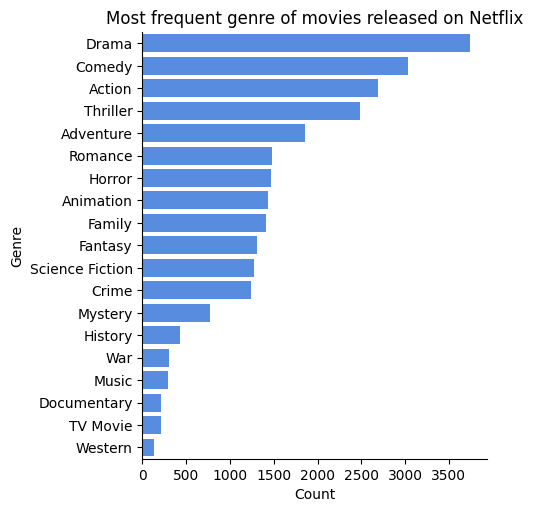

In [126]:
sns.catplot(y='Genre',data=MyData,kind='count',order = MyData['Genre'].value_counts().index,color= '#4287f5')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.title('Most frequent genre of movies released on Netflix')
plt.show()

## Which has highest votes in vote avg column?

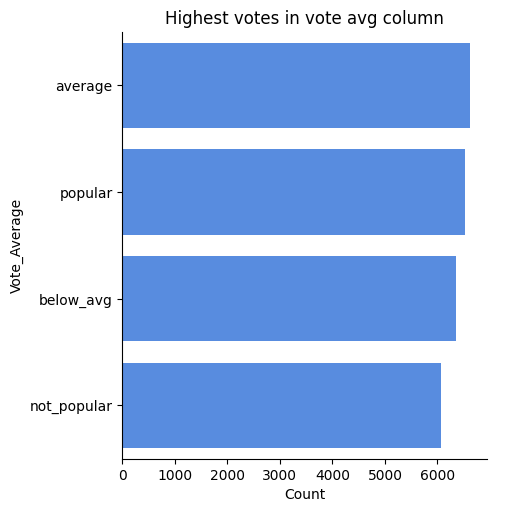

In [128]:
sns.catplot(y='Vote_Average',data=MyData,kind='count',order = MyData['Vote_Average'].value_counts().index,color= '#4287f5')
plt.xlabel('Count')
plt.ylabel('Vote_Average')
plt.title('Highest votes in vote avg column')
plt.show()

## What movie got the highest popularity? what's its genre?

In [134]:
MyData[MyData['Popularity'] == MyData['Popularity'].max()]
MyData.loc[MyData['Popularity'].idxmax()]

,0
Release_Date,2021
Title,Spider-Man: No Way Home
Popularity,5083.954
Vote_Count,8940
Vote_Average,popular
Genre,Action


## What movie got the lowest popularity? what's its genre?

In [138]:
MyData[MyData['Popularity'] == MyData['Popularity'].min()]


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25787,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25788,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25789,2021,The United States vs. Billie Holiday,13.354,152,average,History
25790,1984,Threads,13.354,186,popular,War
25791,1984,Threads,13.354,186,popular,Drama
25792,1984,Threads,13.354,186,popular,Science Fiction


## Which year has the most filmmed movies?

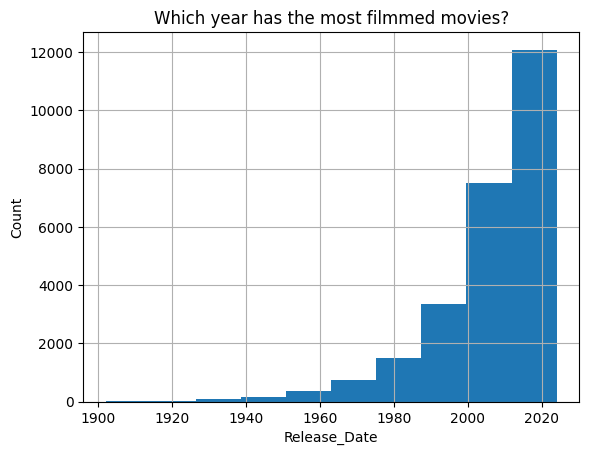

In [142]:
MyData['Release_Date'].hist()
plt.xlabel('Release_Date')
plt.ylabel('Count')
plt.title('Which year has the most filmmed movies?')
plt.show()

## Conclusion